<a href="https://colab.research.google.com/github/SindhuMH/cartoon_generator/blob/image_generator_codes/stable_diffusion_image_gen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q diffusers transformers accelerate safetensors

In [2]:
from google.colab import drive
drive.mount('/content/drive')

OUTPUT_ROOT = '/content/drive/MyDrive/panchatantra_assets'
import os
os.makedirs(OUTPUT_ROOT, exist_ok=True)

Mounted at /content/drive


Using existing style reference: /content/drive/MyDrive/panchatantra_assets/style_reference.png


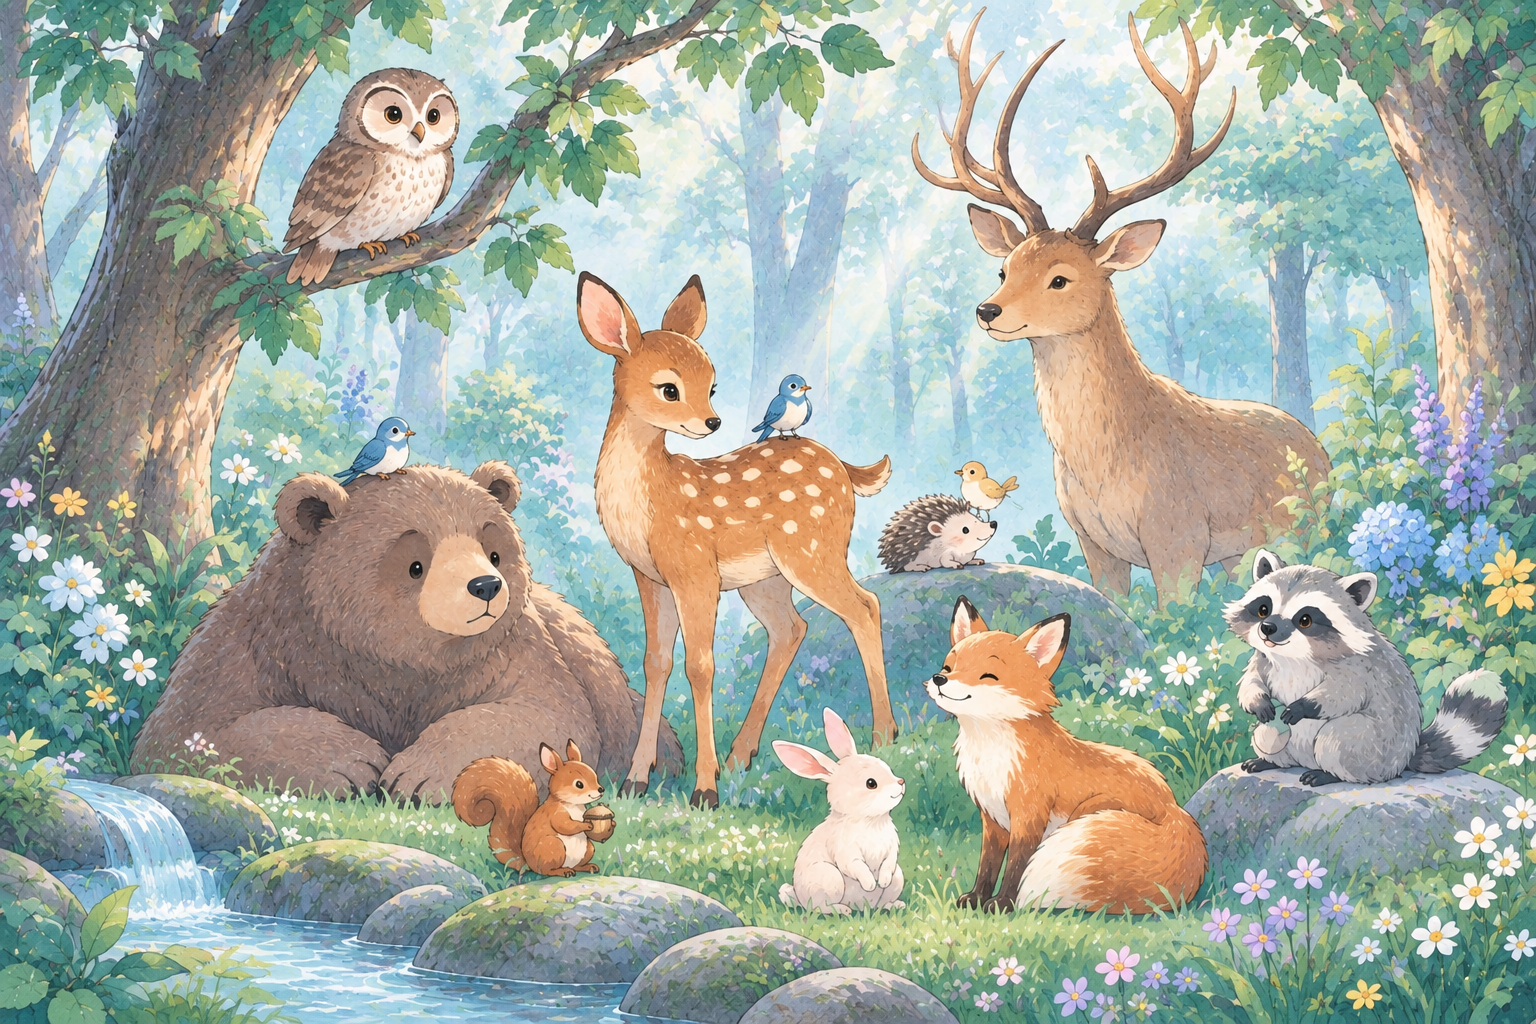

In [3]:
from pathlib import Path
from PIL import Image

STYLE_REF_PATH = Path(OUTPUT_ROOT) / 'style_reference.png'

# if not STYLE_REF_PATH.exists():
#     from google.colab import files
#     print("No saved style reference found — please upload one now.")
#     uploaded = files.upload()
#     uploaded_name = next(iter(uploaded))
#     Image.open(uploaded_name).convert("RGB").save(STYLE_REF_PATH)
#     print(f"Saved to {STYLE_REF_PATH} for future sessions.")
# else:
print(f"Using existing style reference: {STYLE_REF_PATH}")

style_reference = Image.open(STYLE_REF_PATH).convert("RGB")
style_reference

In [4]:
import torch
from PIL import Image

from diffusers import AutoPipelineForText2Image
from transformers import CLIPVisionModelWithProjection

[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.


In [5]:
MODEL_ID = "stabilityai/stable-diffusion-xl-base-1.0"

IP_ADAPTER_REPO = "h94/IP-Adapter"
IP_ADAPTER_WEIGHT = "ip-adapter-plus_sdxl_vit-h.safetensors"

# # Your style/reference image
# style_reference = Image.open(
#     "/kaggle/input/YOUR_DATASET/style_reference.png"
# ).convert("RGB")

print("Reference image:", style_reference.size)
# display(style_reference)

image_encoder = CLIPVisionModelWithProjection.from_pretrained(
    IP_ADAPTER_REPO,
    subfolder="models/image_encoder",
    torch_dtype=torch.float16,
)
print("loaded vision encoder")

pipe = AutoPipelineForText2Image.from_pretrained(
    MODEL_ID,
    image_encoder=image_encoder,
    torch_dtype=torch.float16,
    variant="fp16",
)

print("created pipeline")

pipe.load_ip_adapter(
    IP_ADAPTER_REPO,
    subfolder="sdxl_models",
    weight_name=IP_ADAPTER_WEIGHT,
)

pipe.set_ip_adapter_scale(0.45)

print("loaded ip adapter")
pipe.enable_model_cpu_offload()
# pipe.to("cuda")

Reference image: (1536, 1024)


config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

models/image_encoder/model.safetensors: reconstructing file:   0%|          |  0.00B / 2.53GB            

models/image_encoder/model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

...

created pipeline


sdxl_models/ip-adapter-plus_sdxl_vit-h.s(…): reconstructing file:   0%|          |  0.00B /  848MB            

sdxl_models/ip-adapter-plus_sdxl_vit-h.s(…): downloading bytes:           |  0.00B            

There are modules in UNet2DConditionModel that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


loaded ip adapter


In [6]:
prompt = """
A cute little fox character standing in an enchanted forest,
wearing a small cream-colored dress and a blue scarf.
The fox has large expressive eyes and a friendly, playful expression.

Whimsical children's storybook illustration,
elegant character design,
soft pastel colors,
clean shapes,
beautiful detailed environment,
soft lighting,
high quality digital illustration.
"""

negative_prompt = """
photorealistic,
photograph,
3d render,
cgi,
blurry,
low quality,
deformed,
bad anatomy,
extra limbs,
extra fingers,
duplicate character,
multiple characters,
cropped,
text,
watermark,
logo
"""

  0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


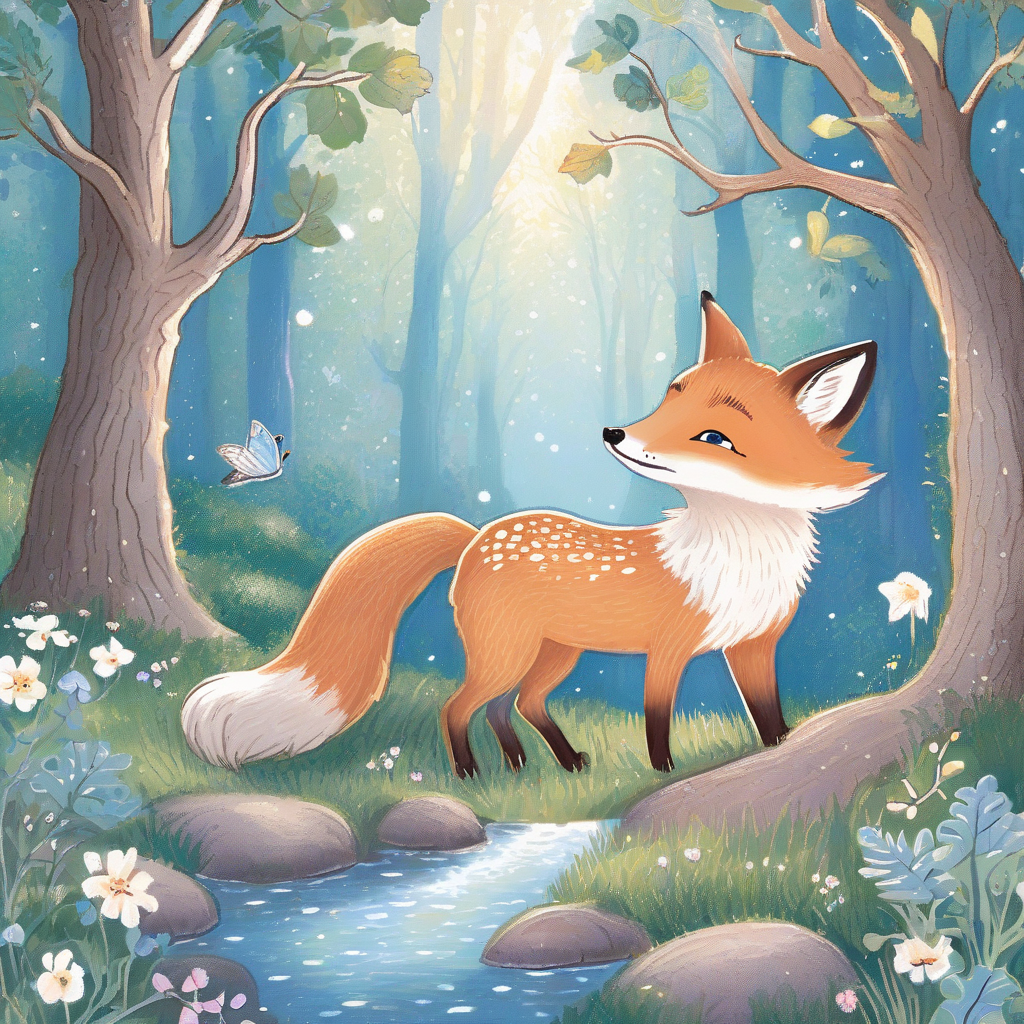

In [7]:
generator = torch.Generator(device="cuda").manual_seed(42)

result = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    ip_adapter_image=style_reference,

    num_inference_steps=25,
    guidance_scale=6.0,

    height=1024,
    width=1024,

    generator=generator,
).images[0]

display(result)

In [8]:
# result.save("/kaggle/working/test_generation.png")

# print("Saved to:")
# print("/kaggle/working/test_generation.png")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/test_generation.png'

# Sample Generation

In [ ]:
config = {
  "story_id": "monkey_and_crocodile",
  "style": {
    "art_style": "detailed storybook illustration, forest setting",
    "negative_prompt": "photorealistic, 3d render, flat vector, watermark, text, signature, blurry, extra limbs, deformed, low quality",
    "character_size": [1024, 1024],
    "place_size": [1344, 768]
  },
  "characters": [
    {
      "id": "monkey",
      "name": "Chintu the Monkey",
      "description": "a friendly young brown monkey with big expressive round eyes, wearing a small red vest, long curled tail, cheerful open-mouth smile, standing pose, full body, plain neutral background"
    },
    {
      "id": "crocodile",
      "name": "Kalu the Crocodile",
      "description": "a chubby green crocodile with rounded snout, small friendly eyes, textured back scales stylized as soft bumps, short stubby legs, standing pose, full body, plain neutral background"
    }
  ],
  "places": [
    {
      "id": "riverbank",
      "name": "River Bank",
      "description": "a lush green riverbank at soft morning light, a large fruit tree with overhanging branches on one side, calm blue river with gentle ripples, distant hills, wide establishing shot, no characters"
    },
    {
      "id": "river_middle",
      "name": "Middle of the River",
      "description": "view from the surface of a calm wide river, gentle ripples, soft morning sky reflected in the water, a few lily pads, wide shot, no characters"
    }
  ]
}

VARIANTS_PER_SUBJECT = 4


In [ ]:
import json

def build_prompt(subject_description, style):
    return f"{subject_description}, {style['art_style']}"

def generate_variants(subject_id, subject_description, style, size, out_dir, num_variants, manifest, category):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    prompt = build_prompt(subject_description, style)

    manifest_entry = {"prompt": prompt, "ip_adapter_scale": 0.45, "variants": []}

    for i in range(1, num_variants + 1):
        print(f"  [{category}:{subject_id}] generating variant {i}/{num_variants}...")
        image = pipe(
                  prompt=prompt,
                  negative_prompt=negative_prompt,
                  ip_adapter_image=style_reference,

                  num_inference_steps=25,
                  guidance_scale=6.0,

                  height=1024,
                  width=1024,

                  generator=generator,
              ).images[0]
        variant_path = out_dir / f"variant_{i}.png"
        image.save(variant_path)
        manifest_entry["variants"].append(str(variant_path))
        torch.cuda.empty_cache()

    manifest[category][subject_id] = manifest_entry


In [ ]:
story_id = config["story_id"]
style = config["style"]
base_dir = Path(OUTPUT_ROOT) / story_id

manifest = {"story_id": story_id, "style": style, "characters": {}, "places": {}}

for char in config.get("characters", []):
    generate_variants(
        subject_id=char["id"],
        subject_description=char["description"],
        style=style,
        size=style["character_size"],
        out_dir=base_dir / "characters" / char["id"],
        num_variants=VARIANTS_PER_SUBJECT,
        manifest=manifest,
        category="characters",
    )

for place in config.get("places", []):
    generate_variants(
        subject_id=place["id"],
        subject_description=place["description"],
        style=style,
        size=style["place_size"],
        out_dir=base_dir / "places" / place["id"],
        num_variants=VARIANTS_PER_SUBJECT,
        manifest=manifest,
        category="places",
    )

manifest_path = base_dir / "manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print(f"Done. Manifest written to {manifest_path}")

**Show canonical character and place images**

In [ ]:
import matplotlib.pyplot as plt

def show_variants(category, subject_id):
    entry = manifest[category][subject_id]
    fig, axes = plt.subplots(1, len(entry["variants"]), figsize=(4 * len(entry["variants"]), 4))
    for ax, path in zip(axes, entry["variants"]):
        ax.imshow(Image.open(path))
        ax.set_title(Path(path).name)
        ax.axis("off")
    plt.suptitle(f"{category}: {subject_id}")
    plt.show()

# Example: show_variants("characters", "monkey")


def set_canonical(category, subject_id, variant_number):
    entry = manifest[category][subject_id]
    src = Path(entry["variants"][variant_number - 1])
    dst = src.parent / "canonical.png"
    dst.write_bytes(src.read_bytes())
    print(f"canonical set: {dst}")

# Example usage after reviewing the grid above:
# set_canonical("characters", "monkey", 2)
# set_canonical("places", "riverbank", 1)